
# SVM with raw impedance spectra on a common frequency grid

This version does **not** compress each spectrum into only `mean/std/min/max`.
Instead, every impedance spectrum is interpolated to the same logarithmic frequency grid and used as a raw spectral input.

Per frequency point, the input channels are:

1. `real(Z)`
2. `imag(Z)`
3. `magnitude = |Z|`
4. `phase = angle(Z)`
5. `log10(frequency)`
6. `dphase_dlogf = derivative of phase with respect to log10(frequency)`

For SVM, the final array is flattened:

```text
(n_samples, n_common_frequencies, n_channels)
→ (n_samples, n_common_frequencies × n_channels)
```


In [1]:

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Optional plotting
import matplotlib.pyplot as plt

RANDOM_STATE = 42
N_COMMON_FREQ = 30

# Change this if your files are somewhere else.
# The code first tries ./dataset/train_data.csv and ./dataset/test_data.csv.
# If that does not exist, it tries ./train_data.csv and ./test_data.csv.
DATA_DIR = Path("dataset") if Path("dataset/train_data.csv").exists() else Path(".")
TRAIN_FILE = DATA_DIR / "train_data.csv"
TEST_FILE  = DATA_DIR / "test_data.csv"

print("Train file:", TRAIN_FILE.resolve())
print("Test file :", TEST_FILE.resolve())


Train file: D:\TUChemnitz\2.Sem\1. Project Lab Embedded Systems\mini-belt-characterization\software_host\MiuLe\dataset\train_data.csv
Test file : D:\TUChemnitz\2.Sem\1. Project Lab Embedded Systems\mini-belt-characterization\software_host\MiuLe\dataset\test_data.csv



## 1. Parser functions

The CSV stores `freq` and `Z` as strings that look like arrays. These functions convert them back to NumPy arrays.


In [2]:

def parse_float_array(s: str) -> np.ndarray:
    """Parse a string representation of a float array, e.g. '[1.0, 2.0, 3.0]'."""
    s = str(s).strip()
    if s.startswith("["):
        s = s[1:]
    if s.endswith("]"):
        s = s[:-1]

    # np.fromstring is robust for comma-separated and whitespace-separated floats.
    arr = np.fromstring(s.replace(",", " "), sep=" ")
    return arr.astype(float)


def parse_complex_array(s: str) -> np.ndarray:
    """
    Parse a string representation of a complex array.

    Handles values like:
        '2.6537056 -6.91795864e-04j'
    by removing spaces inside each complex token.
    """
    s = str(s).strip()
    if s.startswith("["):
        s = s[1:]
    if s.endswith("]"):
        s = s[:-1]

    tokens = [tok.strip() for tok in s.split(",") if tok.strip()]
    values = []
    for tok in tokens:
        tok_clean = tok.replace(" ", "")
        values.append(complex(tok_clean))

    return np.asarray(values, dtype=np.complex128)



## 2. Choose common logarithmic frequency grid

All spectra must be represented at the same frequency points. We choose the overlapping frequency interval from the **training set** only, then create a logarithmically spaced grid.

For this dataset, the common overlap is usually:

```text
10 Hz → 100000 Hz
```

Using the training set to choose the grid avoids using the test set during model design.


In [3]:

def get_frequency_ranges(df: pd.DataFrame):
    """Return arrays of min and max frequency for every spectrum."""
    min_freqs = []
    max_freqs = []

    for freq_str in df["freq"]:
        freq = parse_float_array(freq_str)
        if len(freq) == 0:
            raise ValueError("Empty frequency array found.")
        min_freqs.append(np.min(freq))
        max_freqs.append(np.max(freq))

    return np.asarray(min_freqs), np.asarray(max_freqs)


def choose_common_frequency_grid(train_df: pd.DataFrame, n_points: int = 30) -> np.ndarray:
    """
    Choose a common frequency grid within the overlap of all training spectra.

    We use:
        start = maximum of all minimum frequencies
        stop  = minimum of all maximum frequencies

    This guarantees that interpolation does not require extrapolation.
    """
    min_freqs, max_freqs = get_frequency_ranges(train_df)

    f_start = np.max(min_freqs)
    f_stop  = np.min(max_freqs)

    if f_start >= f_stop:
        raise ValueError(
            f"No common frequency overlap. f_start={f_start}, f_stop={f_stop}"
        )

    common_freq = np.logspace(
        np.log10(f_start),
        np.log10(f_stop),
        n_points,
    )
    return common_freq


train_df_preview = pd.read_csv(TRAIN_FILE)
common_freq = choose_common_frequency_grid(train_df_preview, n_points=N_COMMON_FREQ)

print(f"Common frequency grid: {len(common_freq)} points")
print(f"Start: {common_freq[0]:.6g} Hz")
print(f"Stop : {common_freq[-1]:.6g} Hz")
print("First 5 frequencies:", common_freq[:5])
print("Last 5 frequencies :", common_freq[-5:])


Common frequency grid: 30 points
Start: 10 Hz
Stop : 100000 Hz
First 5 frequencies: [10.         13.73823796 18.87391822 25.92943797 35.6224789 ]
Last 5 frequencies : [ 28072.16203941  38566.20421163  52983.16906284  72789.53843983
 100000.        ]



## 3. Interpolate one spectrum to the common grid

Interpolation is done on the `log10(frequency)` axis because EIS frequencies are normally logarithmically spaced.

The derivative feature is computed as:

```text
dphase_dlogf = d(phase) / d(log10(frequency))
```

This is usually more stable than `dphase / df`, because the frequency range spans several orders of magnitude.


In [4]:

def spectrum_to_raw_features(
    freq: np.ndarray,
    z: np.ndarray,
    common_freq: np.ndarray,
) -> np.ndarray:
    """
    Convert one impedance spectrum into raw spectral features on a common grid.

    Output shape:
        (n_common_frequencies, 6)

    Channels:
        0: real(Z)
        1: imag(Z)
        2: magnitude |Z|
        3: phase angle(Z), unwrapped
        4: log10(frequency)
        5: dphase / dlog10(frequency)
    """
    freq = np.asarray(freq, dtype=float)
    z = np.asarray(z, dtype=np.complex128)

    if len(freq) != len(z):
        raise ValueError(f"freq and Z length mismatch: {len(freq)} vs {len(z)}")

    # Sort by ascending frequency.
    order = np.argsort(freq)
    freq = freq[order]
    z = z[order]

    # Remove duplicate frequencies if any.
    freq_unique, unique_idx = np.unique(freq, return_index=True)
    freq = freq_unique
    z = z[unique_idx]

    log_freq = np.log10(freq)
    log_common = np.log10(common_freq)

    # Interpolate real and imaginary parts separately.
    real_interp = np.interp(log_common, log_freq, z.real)
    imag_interp = np.interp(log_common, log_freq, z.imag)

    z_interp = real_interp + 1j * imag_interp

    magnitude = np.abs(z_interp)
    phase = np.unwrap(np.angle(z_interp))  # radians

    # Derivative of phase with respect to log10(frequency).
    dphase_dlogf = np.gradient(phase, log_common)

    # log10(frequency) as requested. Note: this channel is identical for all samples
    # once a fixed common grid is used. It can be useful as a coordinate channel for
    # neural networks, but for a flattened SVM it is mostly redundant.
    logf_channel = log_common.copy()

    features = np.stack(
        [
            real_interp,
            imag_interp,
            magnitude,
            phase,
            logf_channel,
            dphase_dlogf,
        ],
        axis=1,
    )

    return features



## 4. Load dataset as raw spectral input

After interpolation, the data has shape:

```text
X_raw.shape = (n_samples, 30, 6)
```

For SVM, we flatten it to:

```text
X_flat.shape = (n_samples, 180)
```


In [5]:

def load_raw_spectral_dataset(filepath: Path, common_freq: np.ndarray):
    """
    Load a CSV file and convert every spectrum into raw spectral features.

    Returns:
        X_raw: shape (n_samples, n_common_frequencies, 6)
        y:     shape (n_samples,)
    """
    df = pd.read_csv(filepath)

    X_list = []
    y_list = []

    for row_idx, row in df.iterrows():
        freq = parse_float_array(row["freq"])
        z = parse_complex_array(row["Z"])

        features = spectrum_to_raw_features(freq, z, common_freq)
        X_list.append(features)
        y_list.append(row["Circuit"])

    X_raw = np.stack(X_list, axis=0)
    y = np.asarray(y_list)
    return X_raw, y


print("Loading training data ...")
X_train_full_raw, y_train_full = load_raw_spectral_dataset(TRAIN_FILE, common_freq)

print("Loading final test data ...")
X_test_raw, y_test = load_raw_spectral_dataset(TEST_FILE, common_freq)

print("X_train_full_raw:", X_train_full_raw.shape)
print("X_test_raw      :", X_test_raw.shape)
print("y_train_full    :", y_train_full.shape)
print("y_test          :", y_test.shape)

n_channels = X_train_full_raw.shape[-1]
print(f"\nNumber of channels per frequency point: {n_channels}")
print("Channels: real, imag, magnitude, phase, log10(freq), dphase/dlog10(freq)")


Loading training data ...
Loading final test data ...
X_train_full_raw: (7462, 30, 6)
X_test_raw      : (1865, 30, 6)
y_train_full    : (7462,)
y_test          : (1865,)

Number of channels per frequency point: 6
Channels: real, imag, magnitude, phase, log10(freq), dphase/dlog10(freq)



## 5. Split train/validation and keep test set untouched

The validation set is split from `train_data.csv`. The file `test_data.csv` is kept as the final unseen test set.


In [6]:

# Encode labels
label_encoder = LabelEncoder()
y_train_full_enc = label_encoder.fit_transform(y_train_full)
y_test_enc = label_encoder.transform(y_test)

print(f"Classes ({len(label_encoder.classes_)}):")
print(list(label_encoder.classes_))

# Flatten raw spectral input for SVM.
# Shape: (samples, frequencies, channels) -> (samples, frequencies * channels)
X_train_full_flat = X_train_full_raw.reshape(X_train_full_raw.shape[0], -1)
X_test_flat = X_test_raw.reshape(X_test_raw.shape[0], -1)

X_train_flat, X_val_flat, y_train_enc, y_val_enc = train_test_split(
    X_train_full_flat,
    y_train_full_enc,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_full_enc,
)

print("\nDataset sizes:")
print(f"Train      : {X_train_flat.shape}")
print(f"Validation : {X_val_flat.shape}")
print(f"Final test : {X_test_flat.shape}")

print(f"\nFeature vector length for SVM: {X_train_flat.shape[1]}")
print(f"= {N_COMMON_FREQ} common frequencies × {n_channels} channels")


Classes (9):
['L-R-RCPE', 'L-R-RCPE-RCPE', 'L-R-RCPE-RCPE-RCPE', 'RC-G-G', 'RC-RC-RCPE-RCPE', 'RCPE-RCPE', 'RCPE-RCPE-RCPE', 'RCPE-RCPE-RCPE-RCPE', 'Rs_Ws']

Dataset sizes:
Train      : (5969, 180)
Validation : (1493, 180)
Final test : (1865, 180)

Feature vector length for SVM: 180
= 30 common frequencies × 6 channels



## 6. Scale features

The scaler is fitted only on the training split. Then the same scaler is applied to validation and test data.


In [7]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled   = scaler.transform(X_val_flat)
X_test_scaled  = scaler.transform(X_test_flat)



## 7. Train SVM

`class_weight="balanced"` helps because the `Rs_Ws` class has fewer samples than the other classes.

Start with the simple model first. After that, you can enable the optional grid search below.


In [8]:

print("Training SVM with raw spectral input ...")

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

svm.fit(X_train_scaled, y_train_enc)
print("Done.")


Training SVM with raw spectral input ...
Done.



## 8. Optional hyperparameter tuning

Leave `RUN_GRID_SEARCH = False` for a quick run. Set it to `True` if you want to tune `C` and `gamma` using the validation/training data.

For a thesis/project, tuning is recommended, but it can take longer.


In [9]:

RUN_GRID_SEARCH = False

if RUN_GRID_SEARCH:
    print("Running GridSearchCV ...")

    param_grid = {
        "C": [1, 3, 10, 30, 100],
        "gamma": ["scale", 0.001, 0.003, 0.01, 0.03],
        "class_weight": [None, "balanced"],
    }

    base_svm = SVC(kernel="rbf", random_state=RANDOM_STATE)

    grid = GridSearchCV(
        estimator=base_svm,
        param_grid=param_grid,
        scoring="f1_weighted",
        cv=3,
        n_jobs=-1,
        verbose=1,
    )

    # For grid search, use train + validation data from train_data.csv only.
    X_grid = np.vstack([X_train_scaled, X_val_scaled])
    y_grid = np.concatenate([y_train_enc, y_val_enc])

    grid.fit(X_grid, y_grid)

    print("Best parameters:", grid.best_params_)
    print("Best CV weighted F1:", grid.best_score_)

    svm = grid.best_estimator_



## 9. Evaluate model

Look at both accuracy and F1-score. For imbalanced classes, `macro avg` and `weighted avg` are more informative than accuracy alone.


In [10]:

def evaluate_model(name: str, X, y_true_enc):
    y_pred = svm.predict(X)

    print(f"\n── {name} Results ──────────────────────────────")
    print("Accuracy   :", accuracy_score(y_true_enc, y_pred))
    print("Macro F1   :", f1_score(y_true_enc, y_pred, average="macro", zero_division=0))
    print("Weighted F1:", f1_score(y_true_enc, y_pred, average="weighted", zero_division=0))
    print()
    print(classification_report(
        y_true_enc,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0,
    ))

    return y_pred


y_val_pred = evaluate_model("Validation", X_val_scaled, y_val_enc)
y_test_pred = evaluate_model("Final Test", X_test_scaled, y_test_enc)



── Validation Results ──────────────────────────────
Accuracy   : 0.3864701942397857
Macro F1   : 0.37259125257220194
Weighted F1: 0.36408691241758373

                     precision    recall  f1-score   support

           L-R-RCPE       0.30      0.56      0.39       173
      L-R-RCPE-RCPE       0.25      0.12      0.16       185
 L-R-RCPE-RCPE-RCPE       0.32      0.23      0.27       177
             RC-G-G       0.61      0.75      0.67       174
    RC-RC-RCPE-RCPE       0.56      0.69      0.62       185
          RCPE-RCPE       0.27      0.24      0.26       169
     RCPE-RCPE-RCPE       0.28      0.21      0.24       183
RCPE-RCPE-RCPE-RCPE       0.32      0.23      0.27       183
              Rs_Ws       0.40      0.58      0.47        64

           accuracy                           0.39      1493
          macro avg       0.37      0.40      0.37      1493
       weighted avg       0.37      0.39      0.36      1493


── Final Test Results ────────────────────────────


## 10. Confusion matrix

This helps you see which circuit/material classes are actually being confused.


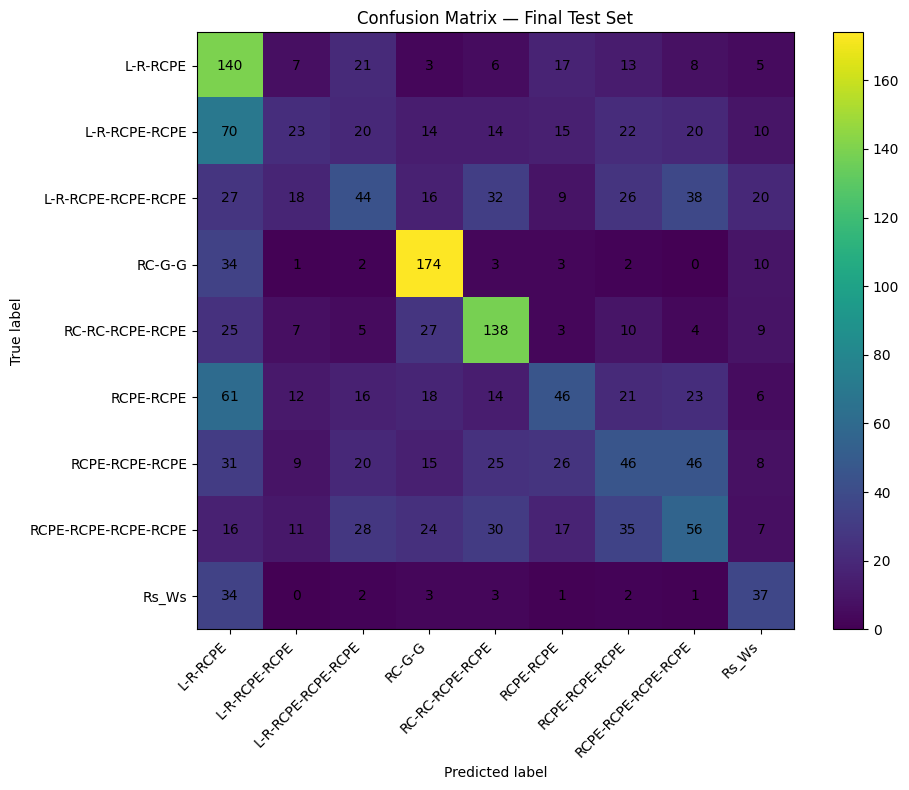

In [11]:

cm = confusion_matrix(y_test_enc, y_test_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm)
ax.set_title("Confusion Matrix — Final Test Set")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(np.arange(len(label_encoder.classes_)))
ax.set_yticks(np.arange(len(label_encoder.classes_)))
ax.set_xticklabels(label_encoder.classes_, rotation=45, ha="right")
ax.set_yticklabels(label_encoder.classes_)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()



## 11. Important note about the `log10(frequency)` feature

Because all spectra are interpolated to the same common frequency grid, the `log10(frequency)` channel is identical for every sample. For an SVM with flattened input, this feature is mostly redundant.

However, it is kept here because:

1. you requested it explicitly;
2. it can be useful later as a coordinate/position channel in a 1D-CNN;
3. it makes the feature tensor self-describing: every row contains both impedance response and its frequency coordinate.

For STM32Cube.AI, the next recommended step is to replace this SVM with a small MLP or 1D-CNN using the same `X_raw` representation.
